## Job Change Predictions
This notebook develops a machine learning pipeline to predict whether a candidate is likely to change jobs based on demographic, educational, and professional information.

The workflow includes data loading, exploratory analysis, preprocessing, feature engineering, model training, and evaluation.

#### 0. Environment Setup
This section configures the notebook environment and initializes utility functions required for the analysis.

In [0]:
# Set environment variables for sagemaker_studio imports

import os
os.environ['DataZoneProjectId'] = 'cmckkznmg9e4dj'
os.environ['DataZoneDomainId'] = 'dzd-dno1z7uulwn65j'
os.environ['DataZoneEnvironmentId'] = 'd019csgggfio13'
os.environ['DataZoneDomainRegion'] = 'us-east-1'

# create both a function and variable for metadata access
_resource_metadata = None

def _get_resource_metadata():
    global _resource_metadata
    if _resource_metadata is None:
        _resource_metadata = {
            "AdditionalMetadata": {
                "DataZoneProjectId": "cmckkznmg9e4dj",
                "DataZoneDomainId": "dzd-dno1z7uulwn65j",
                "DataZoneEnvironmentId": "d019csgggfio13",
                "DataZoneDomainRegion": "us-east-1",
            }
        }
    return _resource_metadata
metadata = _get_resource_metadata()

In [0]:
"""
Logging Configuration

Purpose:
--------
This sets up the logging framework for code executed in the user namespace.
"""

from typing import Optional


def _set_logging(log_dir: str, log_file: str, log_name: Optional[str] = None):
    import os
    import logging
    from logging.handlers import RotatingFileHandler

    level = logging.INFO
    max_bytes = 5 * 1024 * 1024
    backup_count = 5

    # fallback to /tmp dir on access, helpful for local dev setup
    try:
        os.makedirs(log_dir, exist_ok=True)
    except Exception:
        log_dir = "/tmp/kernels/"

    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, log_file)

    logger = logging.getLogger() if not log_name else logging.getLogger(log_name)
    logger.handlers = []
    logger.setLevel(level)

    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")

    # Rotating file handler
    fh = RotatingFileHandler(filename=log_path, maxBytes=max_bytes, backupCount=backup_count, encoding="utf-8")
    fh.setFormatter(formatter)
    logger.addHandler(fh)

    logger.info(f"Logging initialized for {log_name}.")


_set_logging("/var/log/computeEnvironments/kernel/", "kernel.log")
_set_logging("/var/log/studio/data-notebook-kernel-server/", "metrics.log", "metrics")

In [0]:
import logging
from sagemaker_studio import ClientConfig, sqlutils, sparkutils, dataframeutils

logger = logging.getLogger(__name__)
logger.info("Initializing sparkutils")
spark = sparkutils.init()
logger.info("Finished initializing sparkutils")

In [0]:
def _reset_os_path():
    """
    Reset the process's working directory to handle mount timing issues.
    
    This function resolves a race condition where the Python process starts
    before the filesystem mount is complete, causing the process to reference
    old mount paths and inodes. By explicitly changing to the mounted directory
    (/home/sagemaker-user), we ensure the process uses the correct, up-to-date
    mount point.
    
    The function logs stat information (device ID and inode) before and after
    the directory change to verify that the working directory is properly
    updated to reference the new mount.
    
    Note:
        This is executed at module import time to ensure the fix is applied
        as early as possible in the kernel initialization process.
    """
    try:
        import os
        import logging

        logger = logging.getLogger(__name__)
        logger.info("---------Before------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)

        os.chdir("/home/sagemaker-user")

        logger.info("---------After------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)
    except Exception as e:
        logger.exception(f"Failed to reset working directory: {e}")

_reset_os_path()

## 1. Objective
The objective of this project is to predict whether a candidate is likely to change jobs using demographic and professional features.

This is a supervised binary classification problem where the target variable indicates job change intention.

## 2. Imports and configuration

This section imports the core libraries used throughout the notebook for data analysis, visualization, model training, and evaluation.

In [0]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 3. Load Data

Load the processed dataset and perform an initial inspection of its structure, dimensions, and missing values.


In [0]:
# Load processed dataset
df = pd.read_parquet("s3://job-change-github/processed/")

# Preview first rows
df.head()

# Check dataset shape
print(f"Dataset shape: {df.shape}")

# Inspect column types and non-null counts
df.info()

# Review missing values
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Dataset shape: (19158, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  object 
 1   city                    19158 non-null  int32  
 2   city_development_index  19158 non-null  float32
 3   gender                  19158 non-null  int32  
 4   relevent_experience     19158 non-null  int32  
 5   enrolled_university     19158 non-null  int32  
 6   education_level         19158 non-null  int32  
 7   major_discipline        19158 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            19158 non-null  int32  
 10  company_type            19158 non-null  int32  
 11  last_new_job            19158 non-null  int32  
 12  training_hours          19158 non-null  object 
 13  target                  19158 non-null  int32  
 14  senior_cand

experience    65
dtype: int64

## 4. Handle Missing Values

The `experience` feature contains missing values. To retain all observations, missing entries are imputed using the median value of the column.

In [0]:
# Check missing values before imputation
print(f"Missing values in experience before imputation: {df['experience'].isna().sum()}")

# Impute missing values using the mean
experience_mean = df["experience"].mean()
df["experience"] = df["experience"].fillna(experience_mean)

# Check missing values after imputation
print(f"Missing values in experience after imputation: {df['experience'].isna().sum()}")
print(f"Imputed value (mean): {experience_mean:.2f}")

Missing values in experience before imputation: 65
Missing values in experience after imputation: 0
Imputed value (mean): 10.10


## 5. Data Type Conversion and Column Selection

The `training_hours` feature is converted to integer type for consistency, and unnecessary columns are removed before modeling.


In [0]:
# Drop unnecessary columns
df = df.drop(columns=["enrollee_id", "major_discipline"])

# Convert training_hours to integer
df["training_hours"] = df["training_hours"].astype(int)

# Validate updated structure
print(df.dtypes)

city                        int32
city_development_index    float32
gender                      int32
relevent_experience         int32
enrolled_university         int32
education_level             int32
experience                float64
company_size                int32
company_type                int32
last_new_job                int32
training_hours              int64
target                      int32
senior_candidate            int32
dtype: object


## 6. Define and Separate Data


The dataset is split into input features (`X`) and the target variable (`y`). All columns except `target` are used as predictors, while `target` contains the binary label:

- `0`: Candidate is not likely to change jobs
- `1`: Candidate is likely to change jobs

In [0]:
# Define features and target
X = df.drop(columns=["target"])
y = df["target"]

# Validate dimensions
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (19158, 12)
Target shape: (19158,)


## 7. Train-Test Split

The dataset is divided into training and test sets to evaluate model performance on unseen data.  
A standard 80/20 split is used, where 80% of the data is reserved for training and 20% for testing.


In [0]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validate split dimensions
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (15326, 12)
X_test shape: (3832, 12)
y_train shape: (15326,)
y_test shape: (3832,)


## 8. Model Training

An `XGBClassifier` is trained on the training set. The selected hyperparameters control the number of boosting rounds (`n_estimators`), tree complexity (`max_depth`), and learning speed (`learning_rate`).


In [0]:
# Train XGBoost classifier
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## 9. Generate Predictions

Predictions are generated on the test set using the trained XGBoost model. These outputs will be used to assess classification performance.


In [0]:
# Generate class predictions
y_pred = model.predict(X_test)

# Generate predicted probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Preview predictions
print("Predicted classes:", y_pred[:10])
print("Predicted probabilities:", y_pred_proba[:10])

Predicted classes: [0 1 0 0 0 1 0 0 1 0]
Predicted probabilities: [0.03560223 0.67041606 0.03467333 0.35781518 0.32657248 0.5028361
 0.09145816 0.08280491 0.51372683 0.03557974]


## 10. Evaluate Model Accuracy

The model’s accuracy is computed by comparing the predicted labels (`y_pred`) with the true labels in the test set (`y_test`). Accuracy represents the proportion of correctly classified observations.

In [0]:
# Compute model accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display result
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 79.38%


## 11. Feature Importance

This section examines which input variables contribute most to the model’s predictions. Feature importance scores help interpret the relative influence of each feature in the trained XGBoost model.


               Feature  Importance
city_development_index    0.237668
          company_type    0.209370
      senior_candidate    0.117431
       education_level    0.089870
   relevent_experience    0.075898
          company_size    0.056900
          last_new_job    0.039983
            experience    0.035603
                  city    0.035170
        training_hours    0.034916
   enrolled_university    0.033998
                gender    0.033194


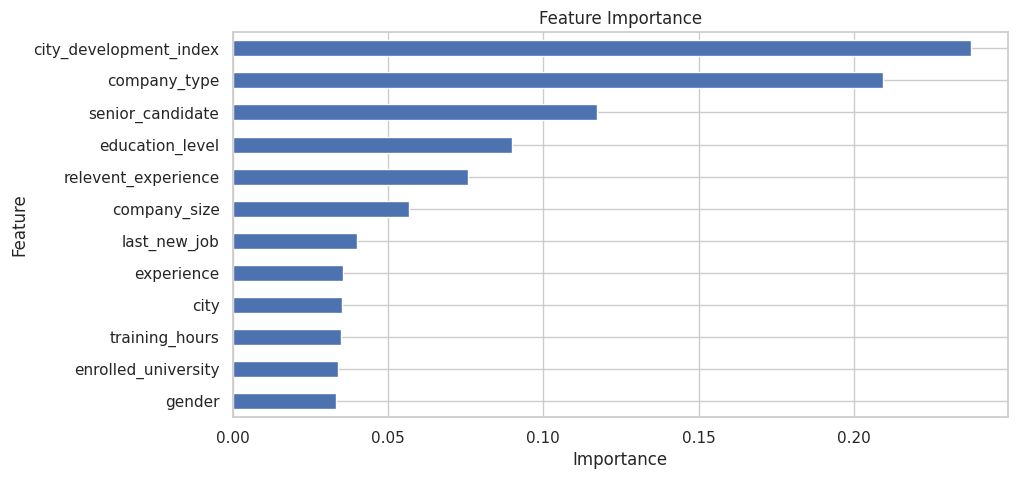

In [0]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.to_string(index=False))

importance.sort_values(by="Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 5),
    legend=False
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 12. Confusion Matrix

The confusion matrix provides a detailed summary of the model’s classification performance by comparing predicted and actual labels.

- **True Negative (TN):** predicted 0, actual 0
- **False Positive (FP):** predicted 1, actual 0
- **False Negative (FN):** predicted 0, actual 1
- **True Positive (TP):** predicted 1, actual 1

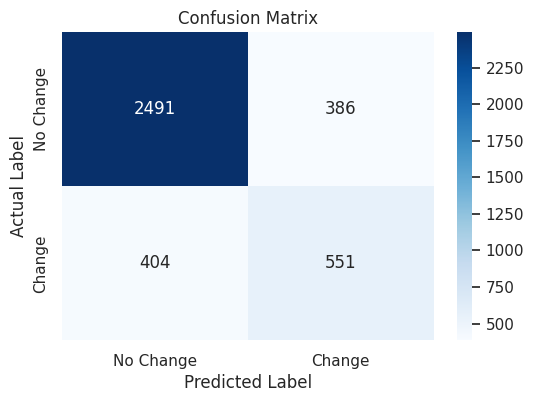

In [0]:
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Change", "Change"],
    yticklabels=["No Change", "Change"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

## 13. Classification Report

The classification report provides a detailed summary of model performance using precision, recall, F1-score, and support for each class.

- **Precision:** proportion of predicted positives that are correct
- **Recall:** proportion of actual positives correctly identified
- **F1-score:** harmonic mean of precision and recall
- **Support:** number of actual instances in each class


In [0]:
from sklearn.metrics import classification_report

# Print classification report with class names
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Change", "Change"]
))

              precision    recall  f1-score   support

   No Change       0.86      0.87      0.86      2877
      Change       0.59      0.58      0.58       955

    accuracy                           0.79      3832
   macro avg       0.72      0.72      0.72      3832
weighted avg       0.79      0.79      0.79      3832



The results indicate that the model achieves stronger performance on the majority class (`No Change`) than on the minority class (`Change`). This suggests that further tuning or class balancing strategies may improve detection of positive cases.

## 14.  Correct unbalanced data
The target variable is imbalanced, meaning one class appears more frequently than the other.  
To reduce this imbalance during training, the ratio between the majority class (`0`) and the minority class (`1`) is calculated and used as `scale_pos_weight` in the XGBoost model.

This parameter increases the importance of the minority class and may improve recall for positive cases.

In [0]:
# Compute class imbalance ratio
class_counts = y_train.value_counts()
scale = class_counts[0] / class_counts[1]

print(f"scale_pos_weight: {scale:.2f}")

scale_pos_weight: 3.01


## 15. Retrain the Model with Class Weighting
To reduce the effect of class imbalance, the model is trained again using the calculated `scale_pos_weight`.  
This parameter increases the penalty for misclassifying minority-class observations and can improve recall for class `1`.

In [0]:
# Train XGBoost with class imbalance adjustment
model_balanced = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale
)

model_balanced.fit(X_train, y_train)

print("Balanced model training completed successfully.")

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## 16. Evaluate the Improved Model
The retrained model is evaluated on the test set to determine whether class weighting improves predictive performance, especially for the minority class.


Original model accuracy: 79.38%
Balanced model accuracy: 78.50%


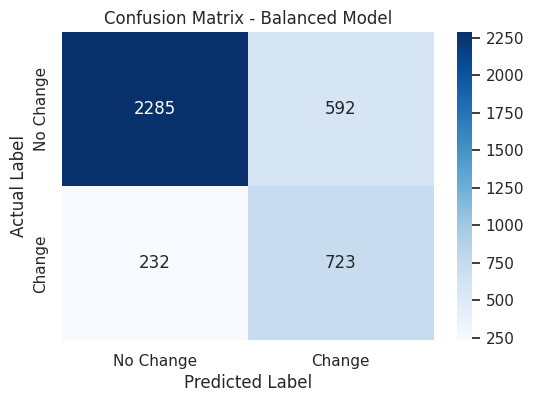

Classification Report - Balanced Model
              precision    recall  f1-score   support

   No Change       0.91      0.79      0.85      2877
      Change       0.55      0.76      0.64       955

    accuracy                           0.78      3832
   macro avg       0.73      0.78      0.74      3832
weighted avg       0.82      0.78      0.79      3832



In [0]:
# Generate predictions with the balanced model
y_pred_balanced = model_balanced.predict(X_test)

# Compute accuracy
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)

print(f"Original model accuracy: {accuracy:.2%}")
print(f"Balanced model accuracy: {accuracy_balanced:.2%}")

# Confusion matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Change", "Change"],
    yticklabels=["No Change", "Change"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Balanced Model")
plt.show()

# Classification report
print("Classification Report - Balanced Model")
print(classification_report(
    y_test,
    y_pred_balanced,
    target_names=["No Change", "Change"]
))

#### 17. Finish session

In [0]:
"""
Stop spark session and associated Athena Spark session
"""

from IPython import get_ipython as _get_ipython
_get_ipython().user_ns["spark"].stop()